In [1]:
import os
import glob
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from preprocessing import normalize_bands

# Paths
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "datas")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "week2b")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Config
PATCH_SIZE = 7
SAMPLES_PER_IMAGE = 25000
RANDOM_SEED = 42

In [2]:
def extract_sampled_patches(data, patch_size, num_samples, seed=42):
    H, W, B = data.shape
    margin = patch_size // 2

    padded = np.pad(
        data,
        ((margin, margin), (margin, margin), (0, 0)),
        mode='constant',
        constant_values=0
    )

    rng = np.random.default_rng(seed)
    rows = rng.integers(0, H, size=num_samples)
    cols = rng.integers(0, W, size=num_samples)

    patches = np.zeros((num_samples, B, patch_size, patch_size), dtype=np.float32)
    coords = np.zeros((num_samples, 2), dtype=np.int32)

    for i in range(num_samples):
        r, c = rows[i], cols[i]
        patch = padded[r:r+patch_size, c:c+patch_size, :]
        patches[i] = patch.transpose(2, 0, 1)
        coords[i] = [r, c]

    return patches, coords

In [13]:
search_pattern = os.path.join(DATA_DIR, "**", "*-SPECTRAL_IMAGE.TIF")
tif_files = sorted(glob.glob(search_pattern, recursive=True))

print(f"Found {len(tif_files)} files")

tif_files  # preview

Found 7 files


['E:\\SEM_6\\Minor Project\\datas\\ENMAP01-____L2A-DT0000044635_20230923T050553Z_016_V010502_20251017T155036Z\\ENMAP01-____L2A-DT0000044635_20230923T050553Z_016_V010502_20251017T155036Z-SPECTRAL_IMAGE.TIF',
 'E:\\SEM_6\\Minor Project\\datas\\ENMAP01-____L2A-DT0000044635_20230923T050607Z_019_V010502_20251017T153554Z\\ENMAP01-____L2A-DT0000044635_20230923T050607Z_019_V010502_20251017T153554Z-SPECTRAL_IMAGE.TIF',
 'E:\\SEM_6\\Minor Project\\datas\\ENMAP01-____L2A-DT0000051947_20231128T051615Z_009_V010502_20251017T152623Z\\ENMAP01-____L2A-DT0000051947_20231128T051615Z_009_V010502_20251017T152623Z-SPECTRAL_IMAGE.TIF',
 'E:\\SEM_6\\Minor Project\\datas\\ENMAP01-____L2A-DT0000058175_20240117T051315Z_001_V010502_20251017T145944Z\\ENMAP01-____L2A-DT0000058175_20240117T051315Z_001_V010502_20251017T145944Z-SPECTRAL_IMAGE.TIF',
 'E:\\SEM_6\\Minor Project\\datas\\ENMAP01-____L2A-DT0000058175_20240117T051328Z_004_V010502_20251017T142827Z\\ENMAP01-____L2A-DT0000058175_20240117T051328Z_004_V010502_202

In [4]:
filepath = tif_files[0]

data = tifffile.imread(filepath)

print("Original shape:", data.shape)

# Convert to (H, W, Bands)
if data.shape[0] > 100 and data.shape[1] > 1000:
    data = data.transpose(1, 2, 0)

print("Converted shape:", data.shape)

data = data.astype(np.float32)

# Normalize
data = normalize_bands(data, method="zscore")

# Extract patches
patches, coords = extract_sampled_patches(
    data, PATCH_SIZE, 1000  # small number for testing
)

print("Patch shape:", patches.shape)

Original shape: (224, 1176, 1209)
Converted shape: (1176, 1209, 224)
Patch shape: (1000, 224, 7, 7)


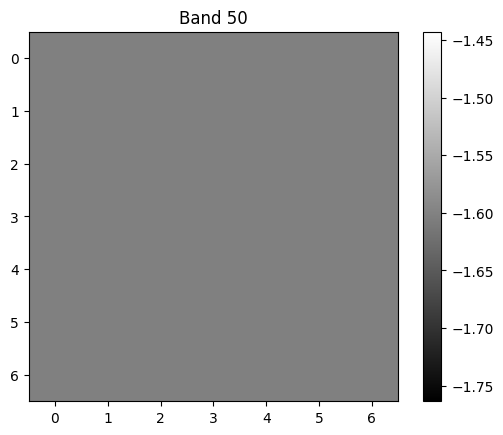

In [5]:
sample = patches[0]  # (224, 7, 7)

# Show one band
plt.imshow(sample[50], cmap='gray')
plt.title("Band 50")
plt.colorbar()
plt.show()

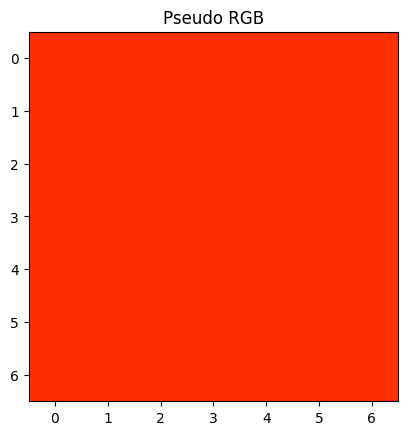

In [6]:
R = sample[50]
G = sample[100]
B = sample[150]

rgb = np.stack([R, G, B], axis=-1)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb)
plt.title("Pseudo RGB")
plt.show()

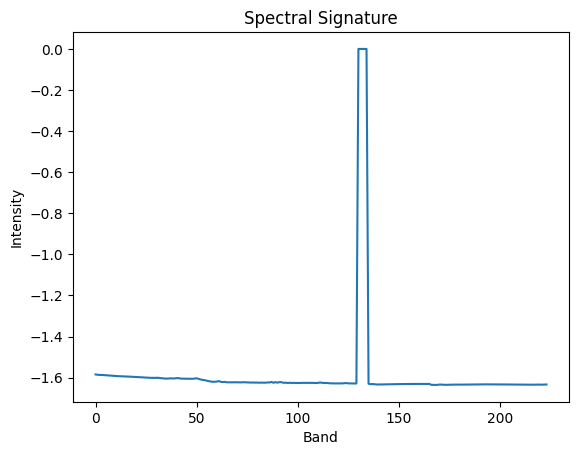

In [7]:
pixel = sample[:, 3, 3]

plt.plot(pixel)
plt.title("Spectral Signature")
plt.xlabel("Band")
plt.ylabel("Intensity")
plt.show()

In [8]:
all_patches = []

for i, filepath in enumerate(tif_files):
    print(f"[{i+1}/{len(tif_files)}] Processing...")

    data = tifffile.imread(filepath)

    if data.shape[0] > 100 and data.shape[1] > 1000:
        data = data.transpose(1, 2, 0)

    data = data.astype(np.float32)
    data = normalize_bands(data, method="zscore")

    patches, _ = extract_sampled_patches(
        data,
        patch_size=PATCH_SIZE,
        num_samples=SAMPLES_PER_IMAGE,
        seed=RANDOM_SEED + i
    )

    all_patches.append(patches)

    print("Batch shape:", patches.shape)

    del data

[1/7] Processing...
Batch shape: (25000, 224, 7, 7)
[2/7] Processing...
Batch shape: (25000, 224, 7, 7)
[3/7] Processing...
Batch shape: (25000, 224, 7, 7)
[4/7] Processing...
Batch shape: (25000, 224, 7, 7)
[5/7] Processing...
Batch shape: (25000, 224, 7, 7)
[6/7] Processing...
Batch shape: (25000, 224, 7, 7)
[7/7] Processing...
Batch shape: (25000, 224, 7, 7)


In [9]:
final_patches = np.concatenate(all_patches, axis=0)

print("Final shape:", final_patches.shape)
print("Memory (GB):", final_patches.nbytes / 1024**3)

Final shape: (175000, 224, 7, 7)
Memory (GB): 7.1555376052856445


In [10]:
out_file = os.path.join(PROCESSED_DIR, "enmap_train_patches.npy")
np.save(out_file, final_patches)

print("Saved to:", out_file)

Saved to: E:\SEM_6\Minor Project\processed_data\enmap_train_patches.npy


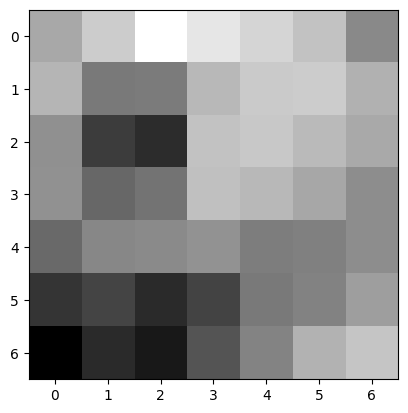

In [12]:
sample = patches[100]

plt.imshow(sample[80], cmap='gray')
plt.show()